# Let's teach a tiny Transformer to execute a circuit

We're going to sample 4-bit reversible circuits, tokenize the **trace** (not English CoT), and train two copies of the same one-layer net: one on the short answer, one on gate→state→gate→state…

The weights-as-rules models live in `handcoded.models`. We import them. We do not paste 800 lines of `nn.Module` into this notebook.

Kernel = this repo's Python. Run from the repo root (or one folder down; we fix `sys.path`). Prefer GPU 2 on the shared box.

In [9]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "handcoded").is_dir() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.plot_style import apply_style
from handcoded import config as hc

apply_style()

n_bits = 2
depth = 5
train_size = 20_000
test_size = 1_000
steps = 10_000
batch_size = 128        # the model is kernel-launch bound, not compute bound:
                        # 4x the batch costs ~1.3x the time, so this is near-free
lr = 1e-3
d_model, n_heads, d_ff = 64, 4, 64
data_seed, test_seed, model_seed, batch_seed = 123, 9000, 42, 2026

# Push these into the package so every default follows them. Without this,
# any call that omits n_bits/depth silently falls back to the packaged value.
hc.configure(n_bits=n_bits, depth=depth, train_size=train_size, test_size=test_size,
             steps=steps, batch_size=batch_size, lr=lr,
             d_model=d_model, n_heads=n_heads, d_ff=d_ff,
             data_seed=data_seed, test_seed=test_seed,
             model_seed=model_seed, batch_seed=batch_seed)


if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
print(f"device={device}  steps={steps}  n_train={train_size}")
print("config:", hc.current())


device=cuda  steps=10000  n_train=20000
config: {'N_BITS': 2, 'N_GATES': None, 'DEPTH': 5, 'TRAIN_SIZE': 20000, 'TEST_SIZE': 1000, 'STEPS': 10000, 'BATCH_SIZE': 128, 'LR': 0.001, 'D_MODEL': 64, 'N_HEADS': 4, 'D_FF': 64, 'DATA_SEED': 123, 'TEST_SEED': 9000, 'MODEL_SEED': 42, 'BATCH_SEED': 2026, 'N_STATES': 4}


## 1. A circuit is just bits and gates

Four bits. Flip / CNOT / swap / Toffoli. Index 0 is the **leftmost** bit.
Let's sample a few and print the gold states. `phi` is the labeler — the net never calls it at inference.

In [10]:
from handcoded.gates import make_circuits, make_gate_names, phi, state_text

print("n_gates", len(make_gate_names(n_bits)), "e.g.", make_gate_names(n_bits)[:6], "...")

circuits = make_circuits(n_bits, seed=0, depth=depth, n_bits=n_bits)
for c in circuits:
    start_bits = state_text([int(b) for b in f"{c.start:0{n_bits}b}"])
    path = [f"{s:0{n_bits}b}" for s in c.states]
    print(f"start={start_bits}  gates={list(c.gates)}  states={path}  answer={c.answer:0{n_bits}b}")
    print("  phi(start, g0) == first state?", phi(c.start, c.gates[0], n_bits) == c.states[0])

n_gates 6 e.g. ['x0', 'x1', 'c01', 'c10', 's01', 's10'] ...
start=11  gates=['c01', 's10', 'c10', 's01', 'c01']  states=['10', '01', '11', '11', '10']  answer=10
  phi(start, g0) == first state? True
start=10  gates=['s01', 'x0', 's10', 's01', 'c10']  states=['01', '11', '11', '11', '01']  answer=01
  phi(start, g0) == first state? True


## 2. Semantic tokens (one state = one token)

Not the character GPT in `src.models.gpt`. `S1000` is a single id. Prompt is always start + gates + `<SEP>`. Then either a short **outcome** (`<COLON>` answer `<EOS>`) or a **process** trace.

In [11]:
from handcoded.tokenizer import make_tokenizer
from handcoded.data import encode_dataset

tok = make_tokenizer(n_bits)
ex = circuits[0]
prompt_ids = tok.prompt(ex)
out_ids = tok.continuation(ex, "outcome")
proc_ids = tok.continuation(ex, "process")

print("vocab", len(tok.tokens), "n_states", tok.n_states)
print("prompt ids ", prompt_ids)
print("prompt     ", tok.decode(prompt_ids))
print("outcome ids", out_ids)
print("outcome    ", tok.decode(out_ids))
print("process ids", proc_ids)
print("process    ", tok.decode(proc_ids))

batch = encode_dataset(circuits, tok, "process").to(device)
print("inputs  shape", tuple(batch.inputs.shape), batch.inputs.dtype)
print("targets shape", tuple(batch.targets.shape))
print("row0 inputs ", batch.inputs[0].tolist())
print("row0 targets", batch.targets[0].tolist())  # -100 on prompt positions

vocab 14 n_states 4
prompt ids  [3, 6, 9, 7, 8, 6, 10]
prompt      S11 c01 s10 c10 s01 c01 <SEP>
outcome ids [11, 2, 12]
outcome     <COLON> S10 <EOS>
process ids [6, 2, 9, 1, 7, 3, 8, 3, 6, 2, 11, 2, 12]
process     c01 S10 s10 S01 c10 S11 s01 S11 c01 S10 <COLON> S10 <EOS>
inputs  shape (2, 19) torch.int64
targets shape (2, 19)
row0 inputs  [3, 6, 9, 7, 8, 6, 10, 6, 2, 9, 1, 7, 3, 8, 3, 6, 2, 11, 2]
row0 targets [-100, -100, -100, -100, -100, -100, 6, 2, 9, 1, 7, 3, 8, 3, 6, 2, 11, 2, 12]


## 3. Peek at the learned net: causal mask + logits

`LearnedOneLayerTransformer`: one causal attention, 4 heads, residual, ReLU MLP, **no LayerNorm**. Let's build one and print shapes.

In [12]:
from handcoded.models import LearnedOneLayerTransformer, build_random_learned_model

model = build_random_learned_model(
    tok, depth, seed=model_seed, d_model=d_model, n_heads=n_heads, d_ff=d_ff, device=device,
)
assert isinstance(model, LearnedOneLayerTransformer)
x = batch.inputs[:2]
logits, attn = model(x, return_attention=True)
print("x      ", tuple(x.shape))
print("logits ", tuple(logits.shape))  # (B, T, vocab)
print("attn   ", tuple(attn.shape))    # (B, heads, T, T)
T = x.shape[1]
causal = torch.ones(T, T, dtype=torch.bool).triu(1)
print("causal mask (1 = blocked), 8x8\n", causal[:8, :8].int().cpu().numpy())
print("attn head0, 6x6\n", attn[0, 0, :6, :6].detach().cpu().numpy().round(3))

x       (2, 19)
logits  (2, 19, 14)
attn    (2, 4, 19, 19)
causal mask (1 = blocked), 8x8
 [[0 1 1 1 1 1 1 1]
 [0 0 1 1 1 1 1 1]
 [0 0 0 1 1 1 1 1]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 0 1 1 1]
 [0 0 0 0 0 0 1 1]
 [0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0]]
attn head0, 6x6
 [[1.    0.    0.    0.    0.    0.   ]
 [0.767 0.233 0.    0.    0.    0.   ]
 [0.1   0.126 0.774 0.    0.    0.   ]
 [0.088 0.221 0.454 0.237 0.    0.   ]
 [0.107 0.063 0.245 0.027 0.558 0.   ]
 [0.137 0.097 0.169 0.117 0.271 0.209]]


## 4. Fixed executors (weights = the rule)

We also have a process Transformer and an outcome Transformer whose buffers *are* φ. No training. If free-run isn't exact, we have a bug — in the package, not in a pasted class.

In [13]:
from handcoded.models import build_fixed_outcome, build_fixed_process
from handcoded.eval import generate
from handcoded.eval import make_generation_evaluation, free_run_metrics

probe = make_circuits(8, seed=1, depth=depth, n_bits=n_bits)
ev = make_generation_evaluation(probe, tok, device)
# Both solutions now live in ONE architecture (UnifiedExecutor): same blocks,
# heads, width and parameter count -- only the weight values differ.
fixed_p = build_fixed_process(tok, depth, device=device).eval()
fixed_o = build_fixed_outcome(tok, depth, device=device).eval()


prompt = torch.tensor([tok.prompt(ex)], device=device)
gen = generate(fixed_p, prompt, max_new_tokens=2 * depth + 3, eos_id=tok.eos)
print("gold process ", tok.decode(tok.prompt(ex) + tok.continuation(ex, "process")))
print("gen. process ", tok.decode(gen[0].tolist()))
gen = generate(fixed_o, prompt, max_new_tokens=2 * depth + 3, eos_id=tok.eos)
print("-----------------------")
print("gold outcome ", tok.decode(tok.prompt(ex) + tok.continuation(ex, "outcome")))
print("gen. outcome ", tok.decode(gen[0].tolist()))

gold process  S11 c01 s10 c10 s01 c01 <SEP> c01 S10 s10 S01 c10 S11 s01 S11 c01 S10 <COLON> S10 <EOS>
gen. process  S11 c01 s10 c10 s01 c01 <SEP> c01 S10 s10 S01 c10 S11 s01 S11 c01 S10 <COLON> S10 <EOS>
-----------------------
gold outcome  S11 c01 s10 c10 s01 c01 <SEP> <COLON> S10 <EOS>
gen. outcome  S11 c01 s10 c10 s01 c01 <SEP> <COLON> S10 <EOS>


## 5. One train step, written out

`train_step` in `handcoded.train` is these five lines. Let's do them on a tiny batch and watch the number move.

In [14]:
from handcoded.data import language_model_loss

tiny = encode_dataset(circuits, tok, "process").to(device)
opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0)
print("loss before", language_model_loss(model, tiny).item())

model.train()
opt.zero_grad(set_to_none=True)
loss = language_model_loss(model, tiny)
loss.backward()
opt.step()

print("loss after ", language_model_loss(model, tiny).item())

loss before 2.7598676681518555
loss after  2.5862536430358887


## 6. Data, schedule and evaluation

Everything the training needs, built once: the corpus, both serializations, the
minibatch schedule, the checkpoint grid, and the held-out evaluators. No model is
trained here.

`ANIMATION_GATES` fixes one circuit that later sections sweep over all $K$ start
states, so the answer matrices and the video all describe the same circuit.

In [15]:
from handcoded.config import make_checkpoints
from handcoded.data import make_batch_schedule
from handcoded.eval import make_circuit_prompts

train = make_circuits(train_size, data_seed, depth, n_bits=n_bits)
test = make_circuits(test_size, test_seed, depth, n_bits=n_bits)

data = {m: encode_dataset(train, tok, m).to(device) for m in ("outcome", "process")}
test_data = {m: encode_dataset(test, tok, m).to(device) for m in ("outcome", "process")}
schedule = make_batch_schedule(len(train), steps, batch_size, batch_seed)
ckpts = make_checkpoints(steps, animation_checkpoints=20)   # 130 -> 30 checkpoints
print("n_ckpts", len(ckpts), "first", ckpts[:10])

train_eval = make_generation_evaluation(train[: min(64, len(train))], tok, device)
test_eval = make_generation_evaluation(test, tok, device)
# Exactly `depth` gates, taken from the active gate set. circuit_answer_matrix
# infers the depth from the prompt length, so a mismatch makes it generate past
# the model's position table and fail with a shape error deep inside generate().
ANIMATION_GATES = [tok.gates[i % len(tok.gates)] for i in range(depth)]
assert len(ANIMATION_GATES) == depth, (ANIMATION_GATES, depth)
circuit_prompts = make_circuit_prompts(ANIMATION_GATES, tok, device)

print("train", len(train), "test", len(test), "checkpoints", len(ckpts))


n_ckpts 31 first [0, 1, 2, 5, 10, 20, 25, 50, 75, 100]
train 20000 test 1000 checkpoints 31


## 7. Train two models on the fixed architecture

This is the only training in the notebook: **two models, one architecture**.

Both exact solutions live in **one** hypothesis
class as different values of the *same* buffers, so here the only variable in the
whole experiment is where the loss is applied:

- same blocks, heads, width, parameter count,
- same random $\theta_0$ (`run_experiment` deep-copies one base per mode),
- and both $\theta^\star_{\rm proc}$ and $\theta^\star_{\rm out}$ provably exist inside it
  (section 6 free-runs each at 1.0 before any training).

So "outcome failed because the architecture cannot represent the outcome executor"
is ruled out by construction, not by argument.

*What to look for:* process should reach a far higher answer accuracy than outcome,
with architecture, parameter count and initialization all held fixed -- so the only
thing that differs is where the loss is applied. `unified_solution_distance` also becomes meaningful, since
both targets finally live in the same space -- though distance to a constructed
solution is a weak competence signal on its own (appendix C.14).

In [16]:
from handcoded.models import build_random_trainable_unified, unified_solution_distance
from handcoded.train import run_experiment

unified_lr = lr
unified_base = build_random_trainable_unified(tok, depth, seed=model_seed, device=device)
print(f"one theta_0, {sum(p.numel() for p in unified_base.parameters()):,} trainable params")

unified_models, unified_history = run_experiment(
    unified_base, data, schedule, unified_lr, ckpts, train_eval, test_eval, tok,
    circuit_prompts, test_loss_data=test_data, loss_eval_size=256, grad_clip_norm=1.0,
)
print(unified_history[["mode", "step", "train_loss", "train_answer_accuracy"]].tail(4))

for mode, trained in unified_models.items():
    print(f"  {mode:8s} ||theta - theta*_proc|| = {unified_solution_distance(trained, fixed_p):8.2f}"
          f"   ||theta - theta*_out|| = {unified_solution_distance(trained, fixed_o):8.2f}")

one theta_0, 180,552 trainable params


supervision modes: 100%|██████████| 2/2 [17:27<00:00, 523.80s/it]


KeyError: "['train_answer_accuracy'] not in index"

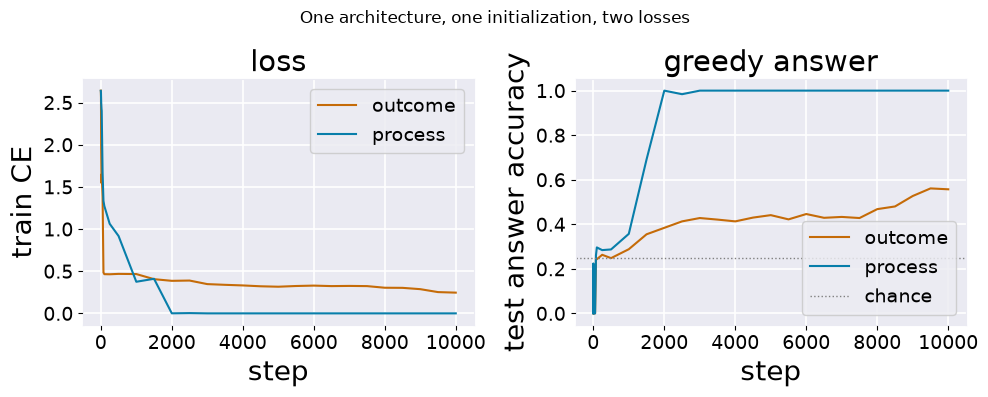

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for mode, color in (("outcome", "#c56b08"), ("process", "#087eaa")):
    h = unified_history[unified_history["mode"] == mode].sort_values("step")
    ax[0].plot(h.step, h.train_loss, color=color, label=mode)
    ax[1].plot(h.step, h.test_answer_accuracy, color=color, label=mode)
ax[0].set(xlabel="step", ylabel="train CE", title="loss")
ax[1].set(xlabel="step", ylabel="test answer accuracy", title="greedy answer",
          ylim=(-0.05, 1.05))
ax[1].axhline(1 / (2 ** n_bits), ls=":", c="grey", lw=1, label="chance")
ax[0].legend(); ax[1].legend()
fig.suptitle("One architecture, one initialization, two losses")
plt.tight_layout()

In [37]:
def param_counts(module):
    trainable = sum(p.numel() for p in module.parameters() if p.requires_grad)
    frozen = sum(p.numel() for p in module.parameters() if not p.requires_grad)
    fixed_buffers = sum(b.numel() for b in module.buffers())
    return trainable, frozen, fixed_buffers


def describe(name, module, n_layers, n_heads):
    trainable, frozen, fixed_buffers = param_counts(module)
    total = trainable + frozen + fixed_buffers
    print(
        f"{name:34s} layers={n_layers:>2} heads={n_heads:>3} "
        f"trainable={trainable:>8,} frozen_params={frozen:>7,} "
        f"fixed_buffers={fixed_buffers:>8,} total={total:>8,}"
    )


print(f"tokenizer: vocab={len(tok.tokens)} n_states={tok.n_states} depth={depth}\n")
# describe("learned (random init)", model, 1, n_heads)
describe("fixed process (unified)", fixed_p, fixed_p.depth, len(fixed_p.blocks[0].heads))
describe("fixed outcome (unified)", fixed_o, fixed_o.depth, len(fixed_o.blocks[0].heads))
for mode, m in unified_models.items():
    describe(f"unified (trained on {mode})", m, m.depth, len(m.blocks[0].heads))

print(f"\nshallow net: d_model={d_model} n_heads={n_heads} d_ff={d_ff} n_layers=1 (block reused across positions)")

print("\nfull per-tensor listing (shape, trainable vs fixed):")
for name, m in [
    ("fixed process (unified)", fixed_p),
    ("fixed outcome (unified)", fixed_o),
    ("unified (trained on outcome)", unified_models["outcome"]),
]:
    print(f"\n--- {name} ---")
    for pname, p in m.named_parameters():
        print(f"  [param ] {pname:35s} {str(tuple(p.shape)):16} requires_grad={p.requires_grad}")
    for bname, b in m.named_buffers():
        print(f"  [buffer] {bname:35s} {str(tuple(b.shape)):16} (fixed, not trained)")


tokenizer: vocab=14 n_states=4 depth=4

fixed process (unified)            layers= 4 heads=  3 trainable=       0 frozen_params=      0 fixed_buffers= 106,383 total= 106,383
fixed outcome (unified)            layers= 4 heads=  3 trainable=       0 frozen_params=      0 fixed_buffers= 106,383 total= 106,383
unified (trained on outcome)       layers= 4 heads=  3 trainable= 106,383 frozen_params=      0 fixed_buffers=       0 total= 106,383
unified (trained on process)       layers= 4 heads=  3 trainable= 106,383 frozen_params=      0 fixed_buffers=       0 total= 106,383

shallow net: d_model=96 n_heads=4 d_ff=96 n_layers=1 (block reused across positions)

full per-tensor listing (shape, trainable vs fixed):

--- fixed process (unified) ---
  [buffer] token_features                      (14, 71)         (fixed, not trained)
  [buffer] position_features                   (17, 71)         (fixed, not trained)
  [buffer] readout                             (14, 71)         (fixed, not train

## 8. Whole-circuit answer matrices

Fix the gate list, vary the start over all 16 states. Row = start, column = predicted answer. Empty row = the model never even emitted `<COLON>`.

fixed outcome shape (4, 4) row-sum mean 1.0
learned outcome shape (4, 4) row-sum mean 1.0
learned process shape (4, 4) row-sum mean 1.0


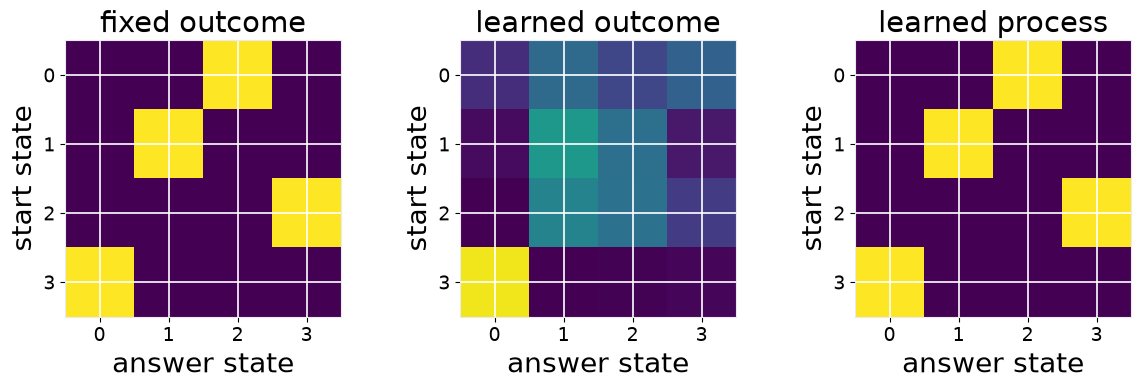

In [38]:
from handcoded.eval import circuit_answer_matrix

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
mats = {
    "fixed outcome": circuit_answer_matrix(fixed_o, circuit_prompts, tok, "outcome"),
    "learned outcome": circuit_answer_matrix(unified_models["outcome"], circuit_prompts, tok, "outcome"),
    "learned process": circuit_answer_matrix(unified_models["process"], circuit_prompts, tok, "process"),
}
for a, (title, mat) in zip(axes, mats.items()):
    a.imshow(mat, vmin=0, vmax=1, cmap="viridis")
    a.set_title(title)
    a.set_xlabel("answer state")
    a.set_ylabel("start state")
    print(title, "shape", mat.shape, "row-sum mean", float(np.asarray(mat).sum(-1).mean().round(3)))
fig.tight_layout()

## 9. Residual stream of the *fixed* outcome model

One block per gate. We hook the hidden state after each block — cumulative execution, not attention pretty-pictures.

gates ['x0', 'x1', 'c01', 'c10'] n_layers 4 layer0 (4, 4)


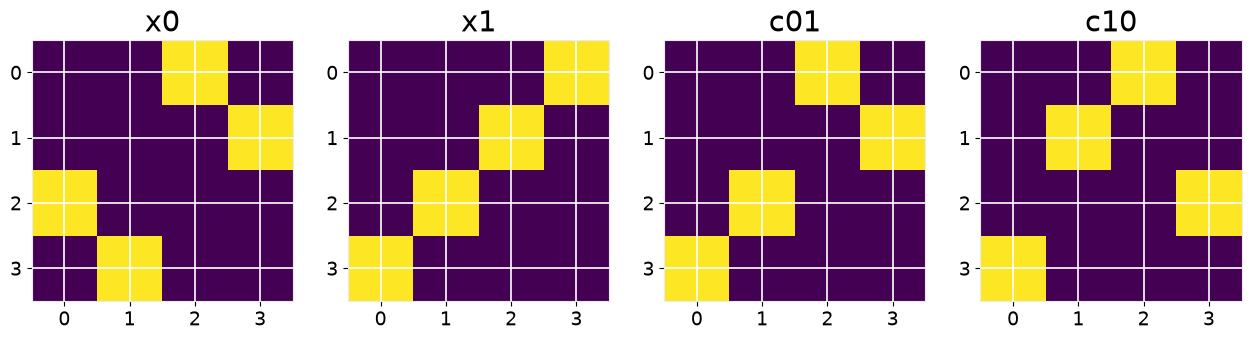

In [39]:
from handcoded.eval import inspect_fixed_circuit

snap = inspect_fixed_circuit(fixed_o, ANIMATION_GATES, tok, device)
print("gates", snap["gates"], "n_layers", len(snap["layers"]), "layer0", snap["layers"][0].shape)
fig, axes = plt.subplots(1, len(snap["layers"]), figsize=(3.2 * len(snap["layers"]), 3.2))
for a, gate, layer in zip(axes, snap["gates"], snap["layers"]):
    a.imshow(layer, cmap="viridis")
    a.set_title(gate)
fig.tight_layout()

## 10. Training dynamics

Same heatmaps over checkpoints. Frames are **measured** steps. Uncomment the first export for the training MP4. The second clip walks **every test circuit** (gold vs learned outcome vs process) with a shared legend.

In [40]:
RUN_ANIMATIONS = True    # slowest cell; set False to skip the MP4 render

from handcoded.animate import (
    animate_all_circuits, animate_training_dynamics, export_training_animation, save_training_mp4,
)
from handcoded.eval import free_run_metrics

if RUN_ANIMATIONS:
    fixed_metrics = {
        "train_loss": language_model_loss(fixed_o, test_data["outcome"].select(slice(0, 32))).item(),
        "train_answer_accuracy_sample": free_run_metrics(fixed_o, train_eval, tok, "outcome")["final_answer"],
        "test_answer_accuracy": free_run_metrics(fixed_o, test_eval, tok, "outcome")["final_answer"],
        "test_exact_continuation": free_run_metrics(fixed_o, test_eval, tok, "outcome")["exact_continuation"],
    }
    anim = animate_training_dynamics(unified_history, snap, fixed_metrics, interval_ms=140, dpi=140)
    save_training_mp4(anim, str(ROOT / "docs/assets/training_dynamics.mp4"))

    catalog = animate_all_circuits(test, unified_models, tok, device, interval_ms=220, dpi=120)
    print("catalog frames", len(test))
    save_training_mp4(catalog, str(ROOT / "docs/assets/all_circuits.mp4"), fps=4, dpi=180)
else:
    print("RUN_ANIMATIONS is False - skipping MP4 render")


Saved MP4: /home/hariguru/aayus/trace/docs/assets/training_dynamics.mp4


circuit matrices:   4%|▍         | 30/692 [00:03<01:26,  7.61it/s]

circuit matrices: 100%|██████████| 692/692 [01:30<00:00,  7.63it/s]


catalog frames 1000
Saved MP4: /home/hariguru/aayus/trace/docs/assets/all_circuits.mp4
